In [1]:
import json
import networkx as nx
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from math import radians, sin, cos, sqrt, atan2

# VAST Challenge 2025 - MC2 EDA

In Mini-Challenge 2, participants will take on the theme of conflict over societal change directly. Two opposing groups representing the fishing and tourism industries are vying for economic development funding and accusing a local government board of bias. Participants will be asked to reconstruct a true timeline with data that comes from both sides.

## Background
Oceanus has enjoyed a relatively simple, fishing-based economy for decades. However, in recent times tourism has greatly expanded and resulted in significant changes. The local government set up an oversight board - Commission on Overseeing the Economic Future of Oceanus (COOTEFOO) - to monitor the current economy and advise how to prepare for the future. It is an appointed board that has no direct power on rules/spending BUT has a lot of clout in the civil service and gets government money to do its job…ostensibly in an unbiased way.

Recently COOTEFOO was hit by a sequence of scandals that roughly break down into two camps:

- Fishing is Living and Heritage (FILAH) accuses the board of being biased toward the new tourism economy and inappropriately attending to the potential in those ventures, ignoring the historical powerhouse of the economy: Getting lots of fish out of the water and off to hungry people. They accuse some COOTEFOO members of bias against fishing.

- Tourism Raises OceanUs Together (TROUT) accuses the board of being biased toward an entrenched interest and constantly “appeasing” the fishing industry, ignoring the new/growing avenues for economic stability. They accuse some members of ignoring the brave-new-world and living in the past.

A journalist, Edwina Darling Moray (E.D. to her friends), at the Haacklee Herald is working on a story about government accountability. She has acquired the datasets that TROUT and FILIAH are working from, which includes meeting minutes and travel records of COOTEFOO members. She also has acquired additional records that TROUT and FILAH did not. Moray has employed a staff programmer to massage the data into a consistent format for analysis – a knowledge graph. You are picking up the work from that programmer to design visualizations to support Moray’s understanding of what is going on. Moray is not a knowledge graph expert, but she understands the workings of Oceanus well. She wants you to design a visual interface to explore the accusations in context and discern which are founded and which are spurious.

## Tasks and Questions:
1. Based on the datasets that TROUT & FILAH have provided, use visual analytics to determine if each group’s accusations are supported by their own record set. In other words, develop a visualization to highlight bias (if present) in TROUT & FILAHS datasets. Is there evidence of bias in the COOTEFOO member actions in either dataset?

2. As a journalist, Ms. Moray would like a more complete picture of the COOTEFOO’s actions and activities. She has arranged to combine the data provided by TROUT and FILAH into a single knowledge graph along with additional records. Design visual analytics approaches for this combined knowledge graph to see how members of COOTEFOO spend their time. Is the committee as a whole biased? Provide visual evidence for your conclusions.

3. The TROUT and FILAH datasets are incomplete. Use your visualizations to compare and contrast conclusions drawn from the TROUT and FILAH datasets separately with behaviors in the whole dataset. Are the accusations of TROUT strengthened, weakened or unchanged when taken in context of the whole dataset?

4. Design a visualization that allows Ms. Moray to pick a person and highlight the differences in that person’s behavior as illustrated through the different datasets. Focus on the contrast in the story each dataset tells.

    a. Pick at least one COOTEFOO member accused by TROUT. Illustrate how your understanding of their activities changed when using the more complete dataset.

    b. What are the key pieces of evidence missing from the original TROUT data that most influenced the change in judgement.

    c. Whose behaviors are most impacted by sampling bias when looking at the FILAH dataset in context of the other data?

    d. Illustrate the bias of the FILAH data in the context of the whole dataset.

## Reflection Questions

Given the task to develop visualizations for knowledge graphs, did you find that the challenge pushed you to develop new techniques for visual representation?

Did you participate in last year’s challenge? If so, did your experience last year help prepare you for this year’s challenge?

What was the most difficult part of working on this year’s data and what could have made it more accessible?

In [2]:
def load_json(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

def create_knowledge_graph(json_data):
    # Create a directed graph
    G = nx.DiGraph()
    
    # Add nodes with their attributes
    if 'nodes' in json_data.keys():
        for node in json_data['nodes']:
            G.add_node(node['id'], **{k: v for k, v in node.items() if k != 'id'})
    
    # Add edges with their attributes
    if 'links' in json_data.keys():
        for edge in json_data['links']:
            G.add_edge(edge['source'], edge['target'], **{k: v for k, v in edge.items() if k not in ['source', 'target']})
    
    return G

In [3]:
root = './2025-data-main/MC2_release/'

filah_data = load_json(root + 'FILAH.json')
trout_data = load_json(root + 'TROUT.json')
journalist_data = load_json(root + 'journalist.json')
road_map_data = load_json(root + 'road_map.json')

# General analysis of each kb

In [9]:
def analysis_kb(kb, col_type='type'):
    graph = create_knowledge_graph(kb)
    print('\nTotal nodes:')
    print(len(graph.nodes))

    print('\nTotal edges:')
    print(len(graph.edges))

    # analysis of nodes
    nodes = pd.DataFrame(kb['nodes'])

    print('\nUnique node types:')
    print(nodes[col_type].unique())

    print('\nNodes with no type:')
    print(nodes[nodes[col_type].isna()].shape)

    entities_ids = {}
    print('\nAnalysis of node types:')
    for node_type in sorted(nodes[col_type].astype(str).unique().tolist()):
        if str(node_type) == 'nan':
            node_type_df = nodes[nodes[col_type].isna()]
        else:
            node_type_df = nodes[nodes[col_type] == node_type]
        
        node_type_df = node_type_df.dropna(axis=1, how='all')
        print(f'Node type: {node_type}, Shape: {node_type_df.shape}, Attributes: {sorted(node_type_df.columns.tolist())}')

        entities_ids[str(node_type)] = node_type_df['id'].unique().tolist()
        
    def get_entity_type_from_id(id):
        for node_type in entities_ids:
            if id in entities_ids[node_type]:
                return node_type
        return None

    # analysis of links    
    links = pd.DataFrame(kb['links'])
    source_types = []
    target_types = []
    for link in links.itertuples():
        source = link.source
        target = link.target

        source_type = get_entity_type_from_id(source)
        target_type = get_entity_type_from_id(target)

        source_types.append(source_type)
        target_types.append(target_type)
    
    links['source_type'] = source_types
    links['target_type'] = target_types

    print('\nAnalysis of links types:')
    for edge_type in links[['source_type', 'target_type']].drop_duplicates().sort_values(by=['source_type', 'target_type']).itertuples():
        source_type, target_type = edge_type.source_type, edge_type.target_type
        edge_type_df = links[(links['source_type'] == source_type) & (links['target_type'] == target_type)]
        
        # Identify if relation is 1:1, 1:N, N:1, N:M based on source/target ids
        source_counts = edge_type_df['source'].value_counts()
        target_counts = edge_type_df['target'].value_counts()
        
        if source_counts.max() == 1 and target_counts.max() == 1:
            granularity = "1:1"
        elif source_counts.max() == 1:
            granularity = "1:N"
        elif target_counts.max() == 1:
            granularity = "N:1"
        else:
            granularity = "N:M"
    
        edge_type_df = edge_type_df.dropna(axis=1, how='all')
        print(f'Edge type: {(source_type, target_type)}, Granularity: {granularity}, Shape: {edge_type_df.shape}') #, Shape: {edge_type_df.shape}, Attributes: {sorted(edge_type_df.columns.tolist())}')
        # if 'role' in edge_type_df.columns:
        #     print('\tRoles:', edge_type_df['role'].unique())

In [10]:
analysis_kb(filah_data)


Total nodes:
396

Total edges:
765

Unique node types:
['meeting' 'entity.person' 'entity.organization' 'topic' 'discussion'
 'plan' nan 'place' 'trip']

Nodes with no type:
(12, 17)

Analysis of node types:
Node type: discussion, Shape: (58, 5), Attributes: ['id', 'label', 'long_title', 'short_title', 'type']
Node type: entity.organization, Shape: (8, 2), Attributes: ['id', 'type']
Node type: entity.person, Shape: (3, 4), Attributes: ['id', 'name', 'role', 'type']
Node type: meeting, Shape: (12, 4), Attributes: ['date', 'id', 'label', 'type']
Node type: nan, Shape: (12, 5), Attributes: ['id', 'label', 'lat', 'lon', 'zone']
Node type: place, Shape: (59, 8), Attributes: ['id', 'label', 'lat', 'lon', 'name', 'type', 'zone', 'zone_detail']
Node type: plan, Shape: (41, 6), Attributes: ['id', 'label', 'long_title', 'plan_type', 'short_title', 'type']
Node type: topic, Shape: (14, 5), Attributes: ['id', 'label', 'long_topic', 'short_topic', 'type']
Node type: trip, Shape: (189, 5), Attribut

In [13]:
analysis_kb(trout_data)


Total nodes:
164

Total edges:
378

Unique node types:
['plan' 'meeting' 'topic' 'place' 'discussion' 'entity.organization' nan
 'entity.person' 'trip']

Nodes with no type:
(3, 17)

Analysis of node types:
Node type: discussion, Shape: (39, 5), Attributes: ['id', 'label', 'long_title', 'short_title', 'type']
Node type: entity.organization, Shape: (8, 2), Attributes: ['id', 'type']
Node type: entity.person, Shape: (6, 4), Attributes: ['id', 'name', 'role', 'type']
Node type: meeting, Shape: (13, 4), Attributes: ['date', 'id', 'label', 'type']
Node type: nan, Shape: (3, 5), Attributes: ['id', 'label', 'lat', 'lon', 'zone']
Node type: place, Shape: (30, 8), Attributes: ['id', 'label', 'lat', 'lon', 'name', 'type', 'zone', 'zone_detail']
Node type: plan, Shape: (33, 6), Attributes: ['id', 'label', 'long_title', 'plan_type', 'short_title', 'type']
Node type: topic, Shape: (14, 5), Attributes: ['id', 'label', 'long_topic', 'short_topic', 'type']
Node type: trip, Shape: (18, 5), Attributes:

In [12]:
analysis_kb(journalist_data)


Total nodes:
740

Total edges:
2436

Unique node types:
['meeting' 'entity.person' 'entity.organization' 'topic' 'discussion'
 'plan' nan 'place' 'trip']

Nodes with no type:
(19, 17)

Analysis of node types:
Node type: discussion, Shape: (101, 5), Attributes: ['id', 'label', 'long_title', 'short_title', 'type']
Node type: entity.organization, Shape: (8, 2), Attributes: ['id', 'type']
Node type: entity.person, Shape: (6, 4), Attributes: ['id', 'name', 'role', 'type']
Node type: meeting, Shape: (16, 4), Attributes: ['date', 'id', 'label', 'type']
Node type: nan, Shape: (19, 5), Attributes: ['id', 'label', 'lat', 'lon', 'zone']
Node type: place, Shape: (159, 8), Attributes: ['id', 'label', 'lat', 'lon', 'name', 'type', 'zone', 'zone_detail']
Node type: plan, Shape: (74, 6), Attributes: ['id', 'label', 'long_title', 'plan_type', 'short_title', 'type']
Node type: topic, Shape: (15, 5), Attributes: ['id', 'label', 'long_topic', 'short_topic', 'type']
Node type: trip, Shape: (342, 5), Attri

In [9]:
analysis_kb(road_map_data, col_type='zone')


Total nodes:
2664

Total edges:
3397

Unique node types:
['commercial' 'residential' 'tourism' 'industrial' 'government'
 'unassigned' 'ferry' 'connector']

Nodes with no type:
(0, 6)

Analysis of node types:
Node type: commercial, Shape: (568, 6), Attributes: ['city_name', 'id', 'latitude', 'longitude', 'name', 'zone']
Node type: connector, Shape: (8, 5), Attributes: ['id', 'latitude', 'longitude', 'name', 'zone']
Node type: ferry, Shape: (13, 5), Attributes: ['id', 'latitude', 'longitude', 'name', 'zone']
Node type: government, Shape: (32, 6), Attributes: ['city_name', 'id', 'latitude', 'longitude', 'name', 'zone']
Node type: industrial, Shape: (154, 6), Attributes: ['city_name', 'id', 'latitude', 'longitude', 'name', 'zone']
Node type: residential, Shape: (1696, 6), Attributes: ['city_name', 'id', 'latitude', 'longitude', 'name', 'zone']
Node type: tourism, Shape: (187, 6), Attributes: ['city_name', 'id', 'latitude', 'longitude', 'name', 'zone']
Node type: unassigned, Shape: (6, 5)

# Answering Specific Questions about data

In [10]:
kb = journalist_data

nodes = pd.DataFrame(kb['nodes'])
links = pd.DataFrame(kb['links'])

unique_node_types = nodes['type'].unique()


entities_ids = {}
for node_type in unique_node_types:  
    if str(node_type) == 'nan':
        node_type_df = nodes[nodes['type'].isna()]
    else:
        node_type_df = nodes[nodes['type'] == node_type]
    entities_ids[str(node_type)] = node_type_df['id'].unique().tolist()


def get_entity_type_from_id(id):
    for node_type in entities_ids:
        if id in entities_ids[node_type]:
            return node_type
    return None

source_types = []
target_types = []
for link in links.itertuples():
    source = link.source
    target = link.target

    source_type = get_entity_type_from_id(source)
    target_type = get_entity_type_from_id(target)

    source_types.append(source_type)
    target_types.append(target_type)

links['source_type'] = source_types
links['target_type'] = target_types

unique_link_types = links.groupby(['source_type', 'target_type']).size().reset_index(name='count')
unique_link_types = unique_link_types.to_dict(orient='records')

In [11]:
# Check if a plan/discussion has multiple industry
links_industry = links.explode('industry')
links_industry = links_industry[links_industry['industry'].notna()]
links_industry['industry'] = links_industry['industry'].apply(lambda x: 'fishing' if 'vessel' in x else 'tourism')
links_industry.groupby(['source_type', 'source']).agg({'industry': 'nunique'})

industry
source_type source                                                      
discussion  affordable_housing_Meeting_10_Travel_Findings_D...         1
            affordable_housing_Meeting_6_Sites_Proposal_Dis...         1
            affordable_housing_Meeting_7_Debate_Discussion             1
            affordable_housing_Meeting_8_Gather_Feedback_Di...         1
            affordable_housing_Meeting_9_Invite_Developers_...         1
...                                                                  ...
plan        waterfront_market_Meeting_7_Benefits_Feasibility           1
            waterfront_market_Meeting_8_Gather_Feedback                1
            waterfront_market_Meeting_9_Report                         1
            waterfront_market_Travel_Harbor_Edge_Grill                 1
            waterfront_market_Travel_Harborfront_Market                1

[112 rows x 1 columns]

## Checkin plan/topic type possible relationships

In [23]:
for i, topic in enumerate(nodes[nodes['type'] == 'topic']['long_topic']):
    print(i, topic)

0 Expanding the tourist wharf/infrastructure in Haacklee
1 Statue to honor John Smoth in Port Grove
2 Deep maintenance to the commercial fishing dock at Himark
3 Money for a new crane at Lomark
4 Fish Vacuum
5 Low-volume unload crane in Haacklee
6 Affordable housing for fishing workers (conflict with short-term rentals)
7 Renaming a park in Himark
8 Putting a name on pictureque harbor area in Port Grove
9 Putting a name on the inspection office in Lomark
10 Establishing a Marine Life Observation Deck in Centralia
11 Hosting an Annual Seafood Festival in Paackland
12 Developing a Heritage Walking Tour in Haacklee
13 Establishing a Waterfront Market in Haacklee
14 Plan for Concert


In [ ]:
{
    0: "Tourism",
    1: "Tourism",
    2: "Fishing",
    3: "Fishing",
    4: "Fishing",
    5: "Fishing",
    6: "Fishing",
    7: "Tourism",
    8: "Tourism",
    9: "Fishing",
    10: "Tourism",
    11: "Tourism",
    12: "Tourism",
    13: "Tourism",
    14: "Tourism"
}

In [18]:

nodes[nodes['type'] == 'plan'].head()

,type,date,label,id,name,role,short_topic,long_topic,short_title,long_title,plan_type,lat,lon,zone,zone_detail,start,end
33,plan,NaN,expanding_tourist_wharf_Travel_Harbor_Route_So...,expanding_tourist_wharf_Travel_Harbor_Route_So...,NaN,NaN,NaN,NaN,expanding_tourist_wharf_Travel_Harbor_Route_So...,Travel to Harbor Route Solutions in Haacklee,Travel,NaN,NaN,NaN,NaN,NaN,NaN
38,plan,NaN,expanding_tourist_wharf_Meeting_9_Report,expanding_tourist_wharf_Meeting_9_Report,NaN,NaN,NaN,NaN,expanding_tourist_wharf_Meeting_9_Report,Get a formal cost impact & environment report,Report,NaN,NaN,NaN,NaN,NaN,NaN
43,plan,NaN,statue_john_smoth_Meeting_8_Proposal,statue_john_smoth_Meeting_8_Proposal,NaN,NaN,NaN,NaN,statue_john_smoth_Meeting_8_Proposal,Present proposal for the statue to honor John ...,proposal,NaN,NaN,NaN,NaN,NaN,NaN
45,plan,NaN,statue_john_smoth_Travel_The_Bait_Stich,statue_john_smoth_Travel_The_Bait_Stich,NaN,NaN,NaN,NaN,statue_john_smoth_Travel_The_Bait_Stich,Travel to The Bait & Stich,Travel,NaN,NaN,NaN,NaN,NaN,NaN
48,plan,NaN,statue_john_smoth_Meeting_9_Feedback,statue_john_smoth_Meeting_9_Feedback,NaN,NaN,NaN,NaN,statue_john_smoth_Meeting_9_Feedback,Gather community feedback on the proposed statue,feedback,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
links[links['target_type'] == 'topic']

,role,source,target,key,sentiment,reason,industry,status,time,source_type,target_type
175,about,expanding_tourist_wharf_Meeting_7_Initial_View...,expanding_tourist_wharf,0,NaN,NaN,NaN,NaN,NaN,discussion,topic
180,about,expanding_tourist_wharf_Travel_Harbor_Route_So...,expanding_tourist_wharf,0,NaN,NaN,NaN,NaN,NaN,discussion,topic
183,plan,expanding_tourist_wharf_Travel_Harbor_Route_So...,expanding_tourist_wharf,0,NaN,NaN,NaN,NaN,NaN,plan,topic
186,about,expanding_tourist_wharf_Meeting_8_Expand_Ideas...,expanding_tourist_wharf,0,NaN,NaN,NaN,NaN,NaN,discussion,topic
191,about,expanding_tourist_wharf_Travel_Harbor_Route_So...,expanding_tourist_wharf,0,NaN,NaN,NaN,NaN,NaN,discussion,topic
...,...,...,...,...,...,...,...,...,...,...,...
719,plan,concert_Meeting_16_Feedback,concert,0,NaN,NaN,NaN,NaN,NaN,plan,topic
722,about,concert_Meeting_16_Road_Closures_Discussion,concert,0,NaN,NaN,NaN,NaN,NaN,discussion,topic
724,plan,concert_Meeting_16_Road_Closures,concert,0,NaN,NaN,NaN,NaN,NaN,plan,topic
727,about,concert_Meeting_16_Communication_Complaints_Di...,concert,0,NaN,NaN,NaN,NaN,NaN,discussion,topic


# Map visualizations

In [44]:
nodes_road = pd.DataFrame(road_map_data['nodes'])
links_road = pd.DataFrame(road_map_data['links'])

In [39]:
# Read geojson as python object
oceanus_map = json.load(open(root + 'oceanus_map.geojson'))
gdf = gpd.GeoDataFrame.from_features(oceanus_map['features'])

def plot_map(gdf):
    ax = gdf.plot(column='Kind', legend=True, figsize=(18, 18))
    for idx, row in gdf.iterrows():
        if row['Name'] is not None:  # Only add text if Name exists
            ax.annotate(
                row['Name'], 
                xy=row.geometry.centroid.coords[0],
                # ha='center', va='center'
            )
    return ax

In [91]:
# person_id = 'Seal'
person_id = 'Teddy Goldstein'
trips_ids = links[links['target'] == person_id]['source'].unique()
places_ids = links[(links['source'].isin(trips_ids) & (links['target_type'] == 'place'))].groupby(['target']).size().reset_index()
places_ids.columns = ['id', 'count']
places_person = nodes[nodes['id'].isin(places_ids['id'])].merge(places_ids, on='id')
places_person.head()

,type,date,label,id,name,role,short_topic,long_topic,short_title,long_title,plan_type,lat,lon,zone,zone_detail,start,end,count
0,place,NaN,The Bait & Stich,2519420987,The Bait & Stich,NaN,NaN,NaN,NaN,NaN,NaN,-165.957039,39.094819,tourism,restaurant,NaN,NaN,3
1,place,NaN,Anchor Way Grill,30188848,Anchor Way Grill,NaN,NaN,NaN,NaN,NaN,NaN,-165.890243,39.666939,tourism,restaurant,NaN,NaN,18
2,place,NaN,Himark City Hall,9196630064,Himark City Hall,NaN,NaN,NaN,NaN,NaN,NaN,-165.884104,39.663550,government,city hall,NaN,NaN,3
3,place,NaN,Lomark Civic Plaza,48475647,Lomark Civic Plaza,NaN,NaN,NaN,NaN,NaN,NaN,-165.597194,39.521993,government,city hall,NaN,NaN,1
4,place,NaN,Dock & Roll Hall of Fame,37828755,Dock & Roll Hall of Fame,NaN,NaN,NaN,NaN,NaN,NaN,-164.358079,39.425973,tourism,restaurant,NaN,NaN,1


In [95]:
sentiment_person = links[(links['target'] == person_id) & (links['sentiment'].notna())].explode('industry').drop_duplicates(subset=['sentiment', 'reason'])
sentiment_person = sentiment_person[sentiment_person['industry'].notna()]
sentiment_person['industry'] = sentiment_person['industry'].apply(lambda x: 'fishing' if 'vessel' in x else 'tourism')
sentiment_person = sentiment_person.groupby(['industry']).agg({'sentiment':'mean'}).reset_index()

,industry,sentiment
0,fishing,0.833333
1,tourism,-0.500000


In [89]:
places_orgs = nodes_road[nodes_road['name'].isin(nodes.loc[nodes['type'] == 'entity.organization', 'id'])]
places_orgs.head()

,zone,city_name,longitude,latitude,id,name
66,tourism,Lomark,-165.551493,39.512590,48483935,Saltwater Serenades
1648,tourism,Paackland,-164.413922,39.437355,37810321,Tours Central Ticketing
1667,industrial,Paackland,-164.347811,39.430420,37867883,Paackland Container Inc.
2421,industrial,Himark,-165.886312,39.654079,3753651731,High Seas Fishing Inc.


In [104]:
sentiment_orgs = links[(links['target'].isin(places_orgs['name']) & (links['sentiment'].notna()))].explode('industry').drop_duplicates(subset=['sentiment', 'reason'])
sentiment_orgs = sentiment_orgs[sentiment_orgs['industry'].notna()]
sentiment_orgs['industry'] = sentiment_orgs['industry'].apply(lambda x: 'fishing' if 'vessel' in x else 'tourism')
sentiment_orgs = sentiment_orgs.groupby(['target','industry']).agg({'sentiment':'mean'}).reset_index()
sentiment_orgs.head()

,target,industry,sentiment
0,High Seas Fishing Inc.,fishing,1.0
1,Paackland Container Inc.,tourism,-0.5
2,Saltwater Serenades,fishing,-1.0
3,Tours Central Ticketing,fishing,-1.0
4,Tours Central Ticketing,tourism,1.0


(38.0, 41.0)

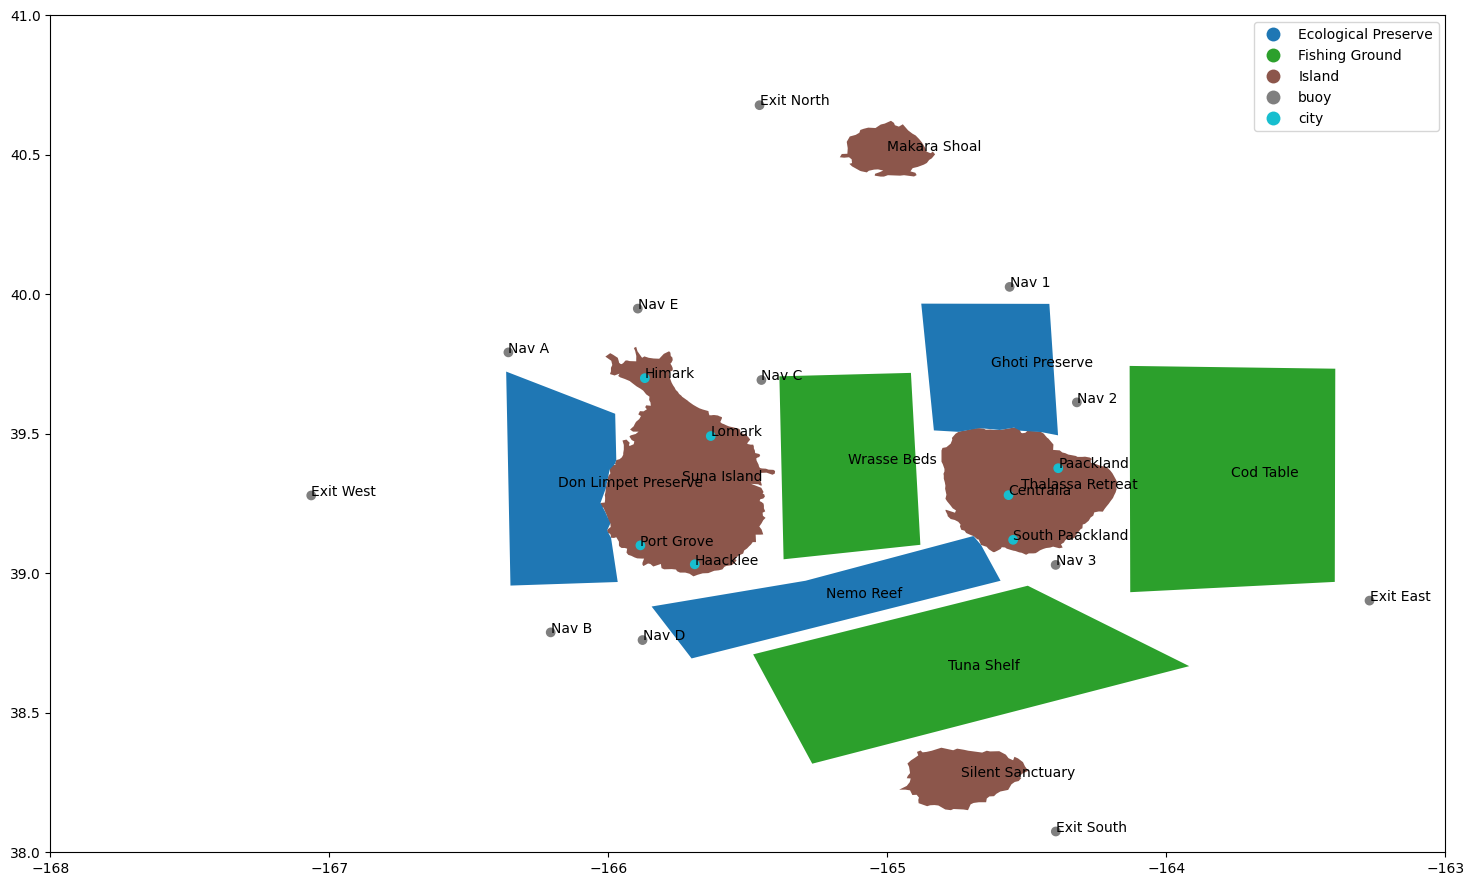

In [122]:
# Scatter plot orgs location and trips location for a person
ax = plot_map(gdf)
# ax.scatter(
#     places_person['lat'], 
#     places_person['lon'], 
#     s=places_person['count']*10, 
#     c='red',
#     alpha=0.5
# )
# ax.scatter(
#     places_orgs['longitude'], 
#     places_orgs['latitude'],
#     s=50,
#     c='yellow',
# )
# ax.scatter(
#     nodes_road['latitude'], 
#     nodes_road['longitude'],
#     s=50,
#     c='yellow',
# )
ax.set_xlim(-168, -163)
ax.set_ylim(38, 41)

In [68]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_rad, lon1_rad = radians(lat1), radians(lon1)
    lat2_rad, lon2_rad = radians(lat2), radians(lon2)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = sin(dlat / 2)**2 + cos(lat1_rad) * cos(lat2_rad) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

In [84]:
def nearest_road_node_and_dist(lat, lon):
    dists = nodes_road.apply(lambda x: haversine_distance_km(lat, lon, x['longitude'], x['latitude']), axis=1)
    min_idx = dists.idxmin()
    return nodes_road.loc[min_idx, 'id'], dists[min_idx]

nodes_coords = nodes[(nodes['lon'].notna()) & (nodes['lat'].notna())]
nodes_coords[['nearest_road', 'nearest_road_dist_km']] = nodes_coords.apply(
    lambda x: pd.Series(nearest_road_node_and_dist(x['lat'], x['lon'])), axis=1
)
nodes_coords = nodes_coords.merge(nodes_road, on='id', how='left')

/tmp/ipykernel_15761/2951371426.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nodes_coords[['nearest_road', 'nearest_road_dist_km']] = nodes_coords.apply(
/tmp/ipykernel_15761/2951371426.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nodes_coords[['nearest_road', 'nearest_road_dist_km']] = nodes_coords.apply(


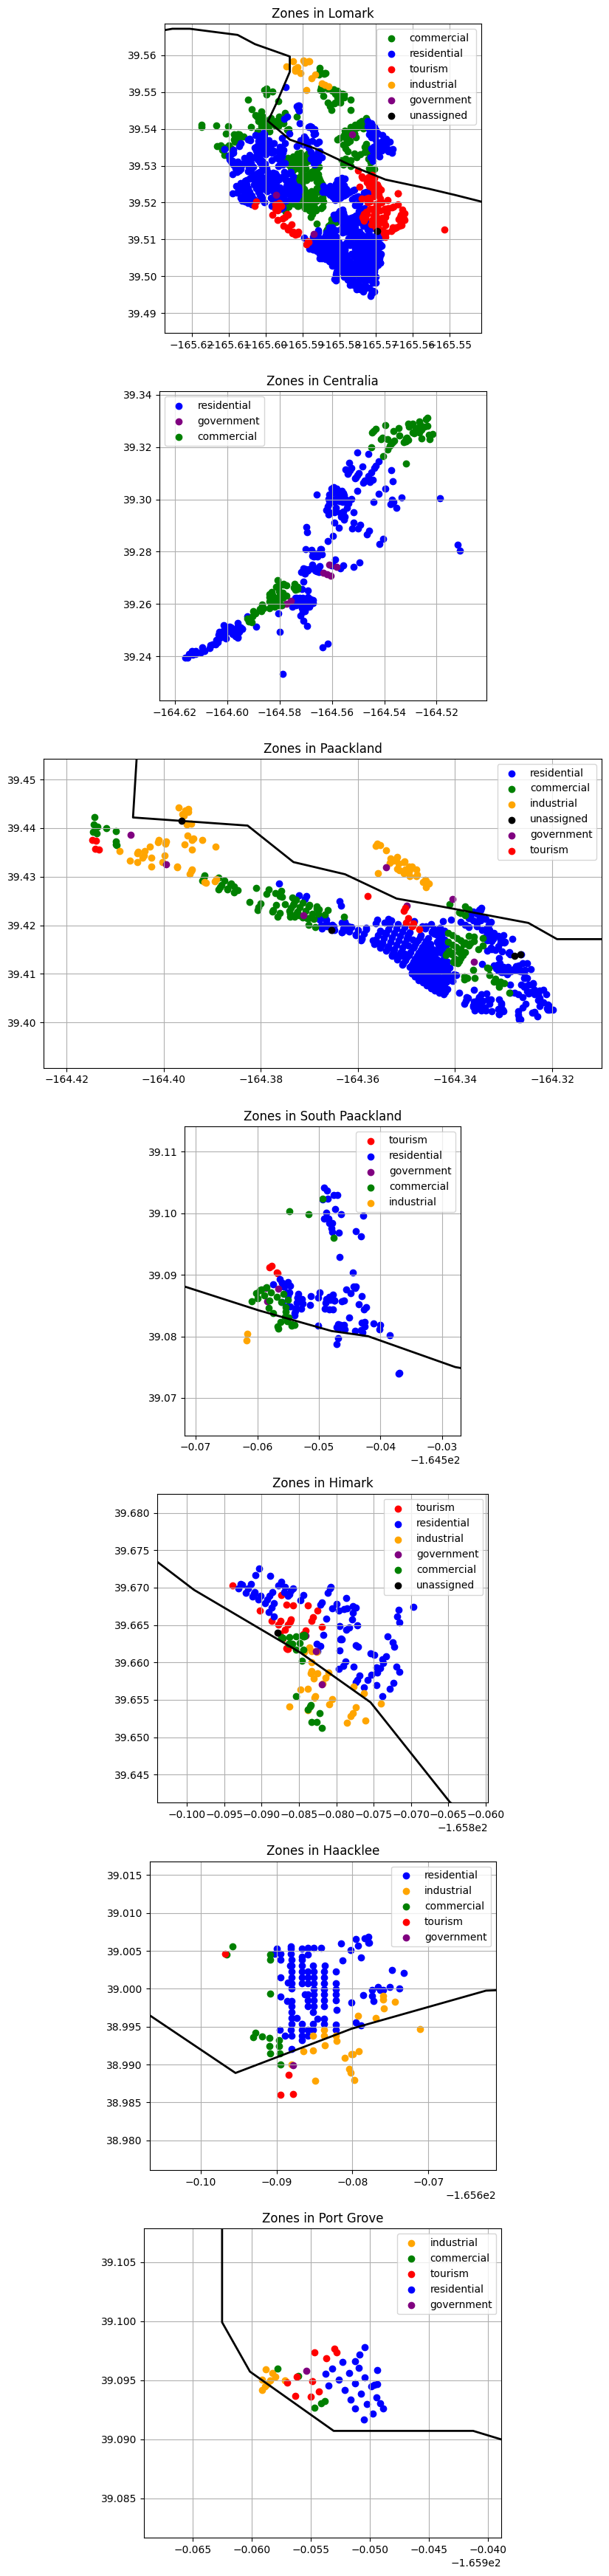

In [120]:
region_geometries = gdf[gdf['type'] == 'Entity.Location.Region']

unique_cities = nodes_road.loc[nodes_road['city_name'].notna(), 'city_name'].unique()

# Create a color map for zones
zone_colors = {
    'residential': 'blue',
    'commercial': 'green',
    'tourism': 'red',
    'industrial': 'orange',
    'government': 'purple',
    'ferry': 'brown',
    'connector': 'gray',
    'unassigned': 'black'
}

# Create a figure with subplots for each city
fig, axes = plt.subplots(len(unique_cities), 1, figsize=(10, 5*len(unique_cities)))

# Plot each city
for idx, city in enumerate(unique_cities):
    city_nodes = nodes_road[nodes_road['city_name'] == city]
    ax = axes[idx] if len(unique_cities) > 1 else axes

    region_geometries.boundary.plot(ax=ax, color='black', linewidth=2)
    
    # Plot points colored by zone
    for zone in city_nodes['zone'].unique():
        zone_data = city_nodes[city_nodes['zone'] == zone]
        ax.scatter(
            zone_data['longitude'], 
            zone_data['latitude'],
            c=zone_colors[zone],
            label=zone
        )
    
    # Set plot limits based on city nodes
    ax.set_xlim(city_nodes['longitude'].min() - 0.01, city_nodes['longitude'].max() + 0.01)
    ax.set_ylim(city_nodes['latitude'].min() - 0.01, city_nodes['latitude'].max() + 0.01)
    
    ax.set_title(f'Zones in {city}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()